[*********************100%***********************]  1 of 1 completed


=== Optimization Results ===
Best Parameters (Fast, Slow): (20, 60)
Best Total Return: 70.91%


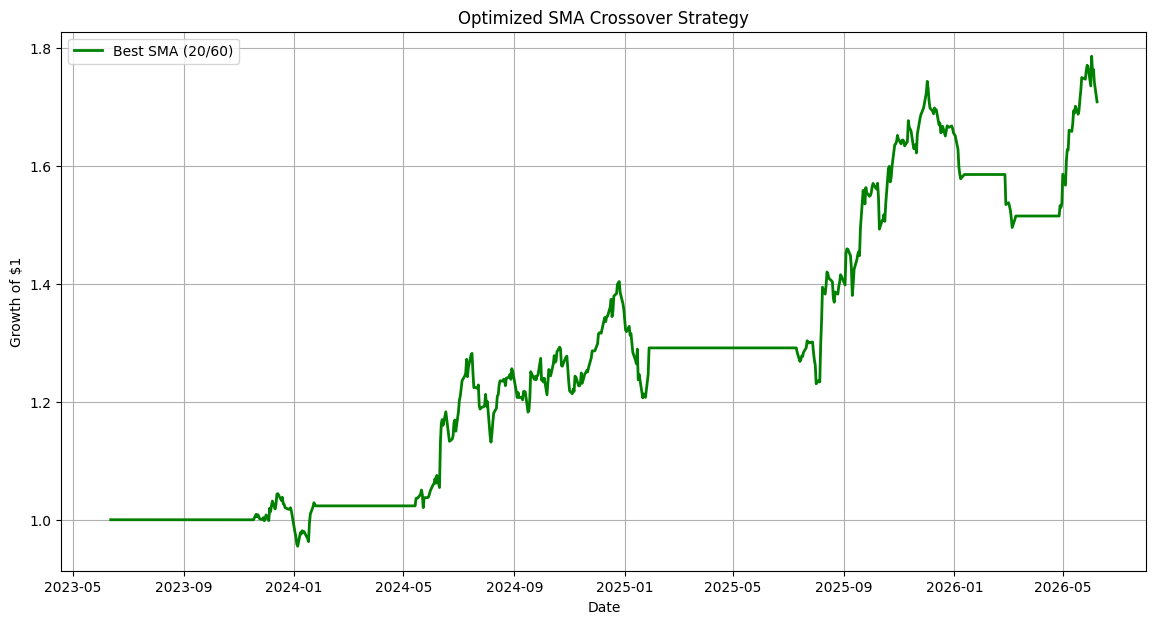

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

# Download data
data = yf.download("AAPL", period="3y", interval="1d")

def backtest_sma_strategy(data, fast=20, slow=50):
    df = data.copy()
    df['SMA_Fast'] = df['Close'].rolling(window=fast).mean()
    df['SMA_Slow'] = df['Close'].rolling(window=slow).mean()
    
    df['Signal'] = 0
    df.loc[df['SMA_Fast'] > df['SMA_Slow'], 'Signal'] = 1
    
    df['Returns'] = df['Close'].pct_change()
    df['Strategy_Returns'] = df['Returns'] * df['Signal'].shift(1)
    
    cumulative = (1 + df['Strategy_Returns']).cumprod()
    total_return = cumulative.iloc[-1] - 1
    
    return total_return, cumulative

# Optimization: Test different SMA periods
results = []
best_return = -float('inf')
best_params = None

for fast, slow in product(range(10, 51, 5), range(30, 151, 10)):
    if fast >= slow:
        continue
    ret, _ = backtest_sma_strategy(data, fast, slow)
    results.append((fast, slow, ret))
    
    if ret > best_return:
        best_return = ret
        best_params = (fast, slow)

print("=== Optimization Results ===")
print(f"Best Parameters (Fast, Slow): {best_params}")
print(f"Best Total Return: {best_return*100:.2f}%")

# Run best strategy
_, best_cumulative = backtest_sma_strategy(data, best_params[0], best_params[1])

plt.figure(figsize=(14, 7))
plt.plot(best_cumulative, label=f'Best SMA ({best_params[0]}/{best_params[1]})', color='green', linewidth=2)
plt.title('Optimized SMA Crossover Strategy')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

The one i wrote

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

# Download data
data = yf.download("AAPL", period="3y", interval="1d")

initial_capital = 100000.0

# Clean column headers if multi-index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

def backtest_strategy(data, fast=20, slow=50):
    df = data.copy()
    df['fast'] = df['Close'].rolling(fast).mean()
    df['slow'] = df['Close'].rolling(slow).mean()

    df['Signal'] = 0
    df.loc[df['fast'] > df['slow'], 'Signal'] = 1
    cash = initial_capital
    shares_owned = 0.0
    df['Position'] = 0.0
    df['Liquid_Cash'] = initial_capital

    # Get integer column positions to use ultra-fast .iat tool
    pos_idx = df.columns.get_loc('Position')
    Liquid_idx = df.columns.get_loc('Liquid_Cash')
    signal_idx = df.columns.get_loc('Signal')
    close_idx = df.columns.get_loc('Close')
    open_idx = df.columns.get_loc('Open')

    df.iat[0, Liquid_idx] = initial_capital
    df.iat[1, Liquid_idx] = initial_capital

    for i in range(2, len(df)):
       current_signal = df.iat[i-1, signal_idx]
       prev_signal = df.iat[i-2, signal_idx]
       new_price = df.iat[i, open_idx]
    
    # 1. Check for Buy Signal (Transition Cash -> Stock)
       if current_signal == 1 and prev_signal == 0:
          aval_cash = df.iat[i-1, Liquid_idx]  # Total liquid cash from previous day
          cash_to_spend = 0.5 * aval_cash  # Risk management: Only invest 50% of available capital
        
          shares_to_buy = cash_to_spend / new_price
          shares_owned += shares_to_buy
          cash -= cash_to_spend 
        
    # 2. Check for Sell Signal (Liquidate Stock -> Cash)
       elif current_signal == 0 and prev_signal == 1:
          cash += (shares_owned * new_price) 
          shares_owned = 0.0
        
    # Assign values directly to the single dataframe cell securely using .iat
    df.iat[i, pos_idx] = shares_owned
    df.iat[i, Liquid_idx] = cash

    Total_Wealth = (df.iat[len(df)-1, pos_idx] * df.iat[len(df)-1, close_idx]) + df.iat[len(df)-1, Liquid_idx]

    return Total_Wealth

x = backtest_strategy(data, 20, 50)
y = f"Fast: 20, Slow: 50"

print("=== Advanced Backtest Results ===")

for fast, slow in product(range(10, 51, 5), range(30, 151, 10)):
    
    # 1. Correct Guard Logic: Skip when windows cross, collide, or are equal
    if fast >= slow:
        continue
        
    # 2. High-Speed Execution: Run the strategy exactly once and store the output
    current_wealth = backtest_strategy(data, fast, slow)
    
    # 3. Optimization Evaluation: Compare the stored value against the highest baseline
    if x < current_wealth:
        x = current_wealth
        y = f"Fast: {fast}, Slow: {slow}"
print(f"Best Parameters: {y} with Final Wealth: ${x:.2f}")

### Options Theory Notes (The Greeks)

- **What are the Greeks?**  
  The Greeks measure how sensitive an option’s price is to different factors. They are essential tools for understanding and managing risk in options trading.

  - **Delta**: Measures how much the option price changes when the underlying stock price moves by $1.
  - **Gamma**: Measures how much Delta changes when the stock price moves by $1 (rate of change of Delta).
  - **Theta**: Measures the rate of time decay — how much the option loses value as each day passes.
  - **Vega**: Measures how much the option price changes when Implied Volatility (IV) moves by 1%.
  - **Rho**: Measures how much the option price changes when interest rates move by 1%.

- **Which Greek is most important for Covered Call sellers and why?**  
  **Theta (Time Decay)** is the most important Greek for covered call sellers.  
  Since we are **selling** options, we want the option to lose value over time. High positive Theta works strongly in our favor — every day that passes, the option we sold becomes cheaper, increasing the chance it expires worthless so we keep the full premium.